# Hyperprior compression of global climate fields

This inference-only notebook turns a pretrained multigrid hyperprior autoencoder into a reproducible compression demonstration. It compresses global climate variables, writes real entropy-coded artifacts to disk, reads them back, reconstructs the fields, and measures both storage efficiency and scientific fidelity. No training or fine-tuning happens here.

## HEALPix: a hierarchical grid for global fields

**HEALPix** (Hierarchical Equal Area isoLatitude Pixelization) divides the sphere into equal-area pixels arranged on iso-latitude rings. It starts from 12 base pixels, and every refinement divides each pixel into four children. For a zoom level $z$, this notebook uses $N_{side}=2^z$ and $N_{pix}=12N_{side}^2$. The three input levels of the following examples contain 12,288 pixels at HPX5, 196,608 pixels at HPX7, and 3,145,728 pixels at HPX9.

Equal pixel area makes global averages straightforward, while the nested parent–child structure makes local coarsening, refinement, and multiscale computation efficient. The image below illustrates how the same 12 base regions are recursively subdivided while preserving the spherical topology.

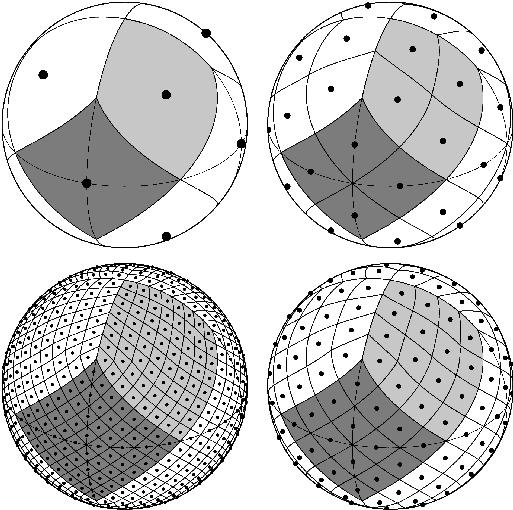

## Multiscale Decomposition

Before inference, the data loader converts the normalized fields into a **coarse field plus finer-scale residuals**. The HPX5 tensor retains the large-scale state. At each finer level, the aligned coarser field is upsampled through the HEALPix hierarchy and subtracted from the finer field. In simplified form,

$$r^z = x^z - \operatorname{up}(x^{z_{coarse}}),$$

so HPX7 and HPX9 emphasize information that was not already represented at a coarser scale. This is an exactly reversible representation before neural compression: multiscale composition upsamples the coarse component and adds the residuals in order. It gives the network explicit access to planetary-scale structure and progressively finer detail instead of asking one representation to model every spatial scale at once. The figure below shows this principle. The original high-resolution field on the left becomes a coarse component and a sequence of residual fields.

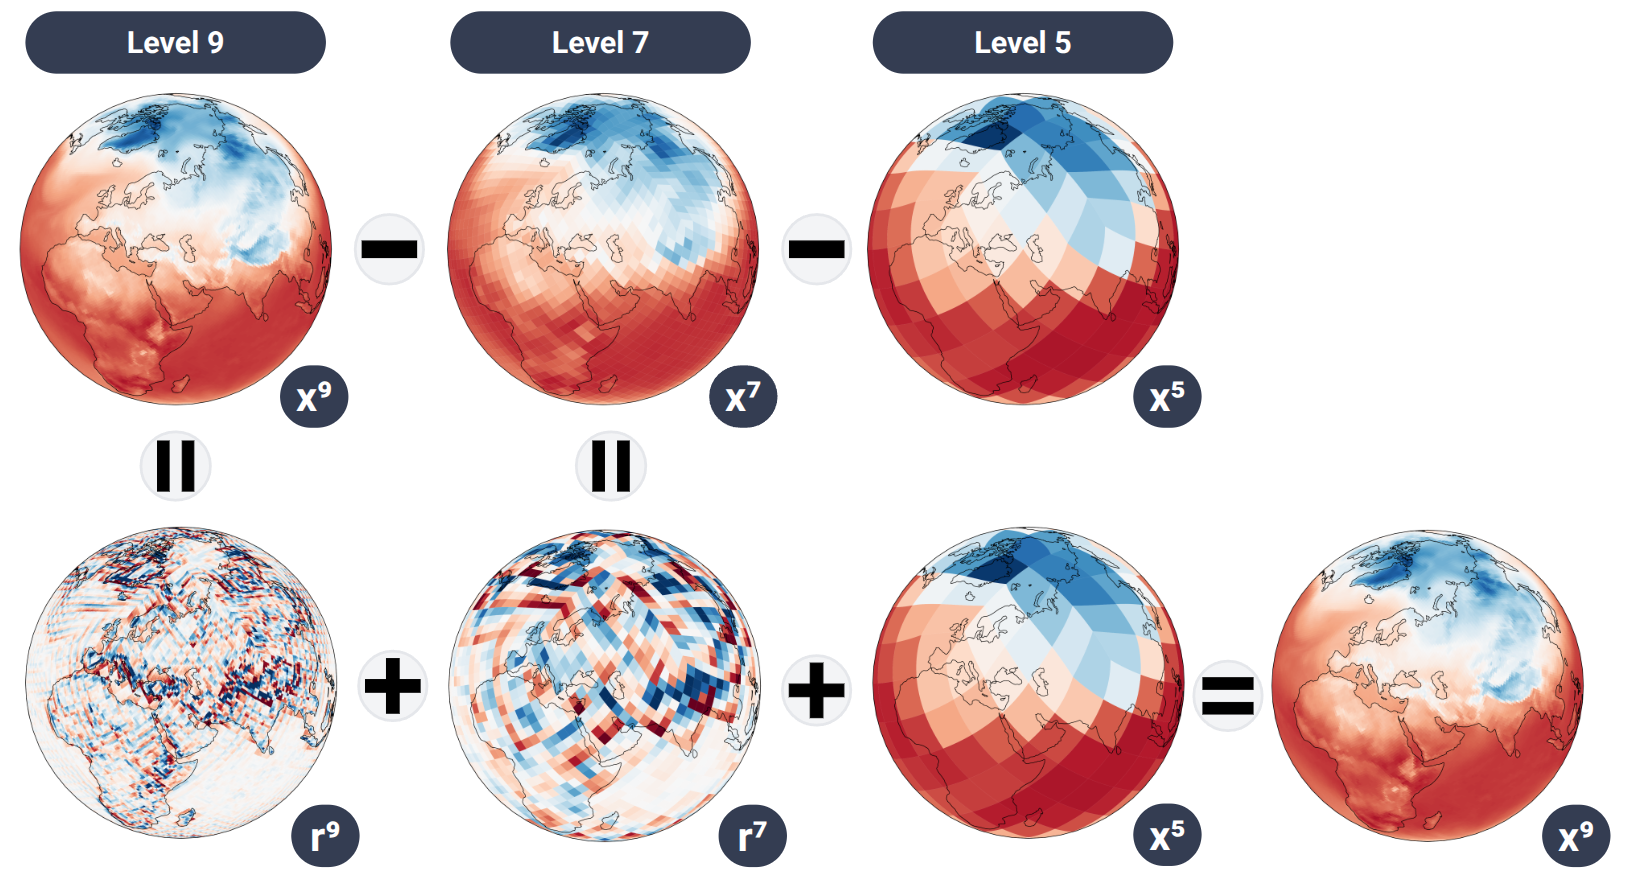

After the autoencoder reconstructs those components, multiscale composition adds them back together to recover the high-resolution field.

## Field-Space autoencoder architecture and Hyperprior compression

The **analysis transform** (encoder $E$) jointly processes the four variables and their HPX5/7/9 components. Field-Space attention blocks exchange information across resolutions using spatial tokens, while multigrid embeddings identify variables and grid locations. Downsampling blocks progressively integrate the fine residuals into a compact latent representation $y$ at HPX7; the configured HPX5 component is retained as passthrough side information so the decoder preserves the broad background state. Inference is deterministic: the model uses the learned posterior mode rather than sampling.

The **synthesis transform** (decoder $D$) reverses this path. It expands the decoded latent through attention and upsampling blocks, predicts reconstructed components at HPX5, HPX7, and HPX9, and then applies multiscale composition. The final HPX9 reconstruction is the sum of the upsampled coarse field and the reconstructed finer residuals. Quantization of the latent representation makes compression lossy, so the evaluation later in this notebook measures the resulting rate–distortion trade-off.

A quantized latent is only compact when it can be encoded with an accurate probability model. The **hyperprior** learns that model from the data. A hyper-analysis network transforms $y$ into a smaller hyperlatent $z$. The quantized $z$ is entropy-coded first with an entropy bottleneck. On the decoder side, $z$ is decoded and passed through the hyper-synthesis network to predict the mean and scale of a conditional Gaussian distribution for each element of $y$. Those probabilities allow likely $y$ values to use fewer bits and unlikely values to use more bits.

The saved artifact contains the entropy-coded $z$ and $y$ byte streams together with the sampling metadata, embeddings, and HPX5 passthrough values required for standalone reconstruction. Decoding therefore proceeds in dependency order: decode $z$, reconstruct the probability parameters for $y$, decode $y$, and finally run the synthesis transform.

The complete pipeline is summarized below. The multiscale HPX fields enter the analysis transform; latent $y$ also feeds the hyper-analysis transform to produce $z$; both streams are entropy-coded into sharded `.pt` artifacts. Reconstruction reads those artifacts from disk, decodes the hyperprior and primary latent, applies the synthesis transform, and composes the output into HPX9 fields.

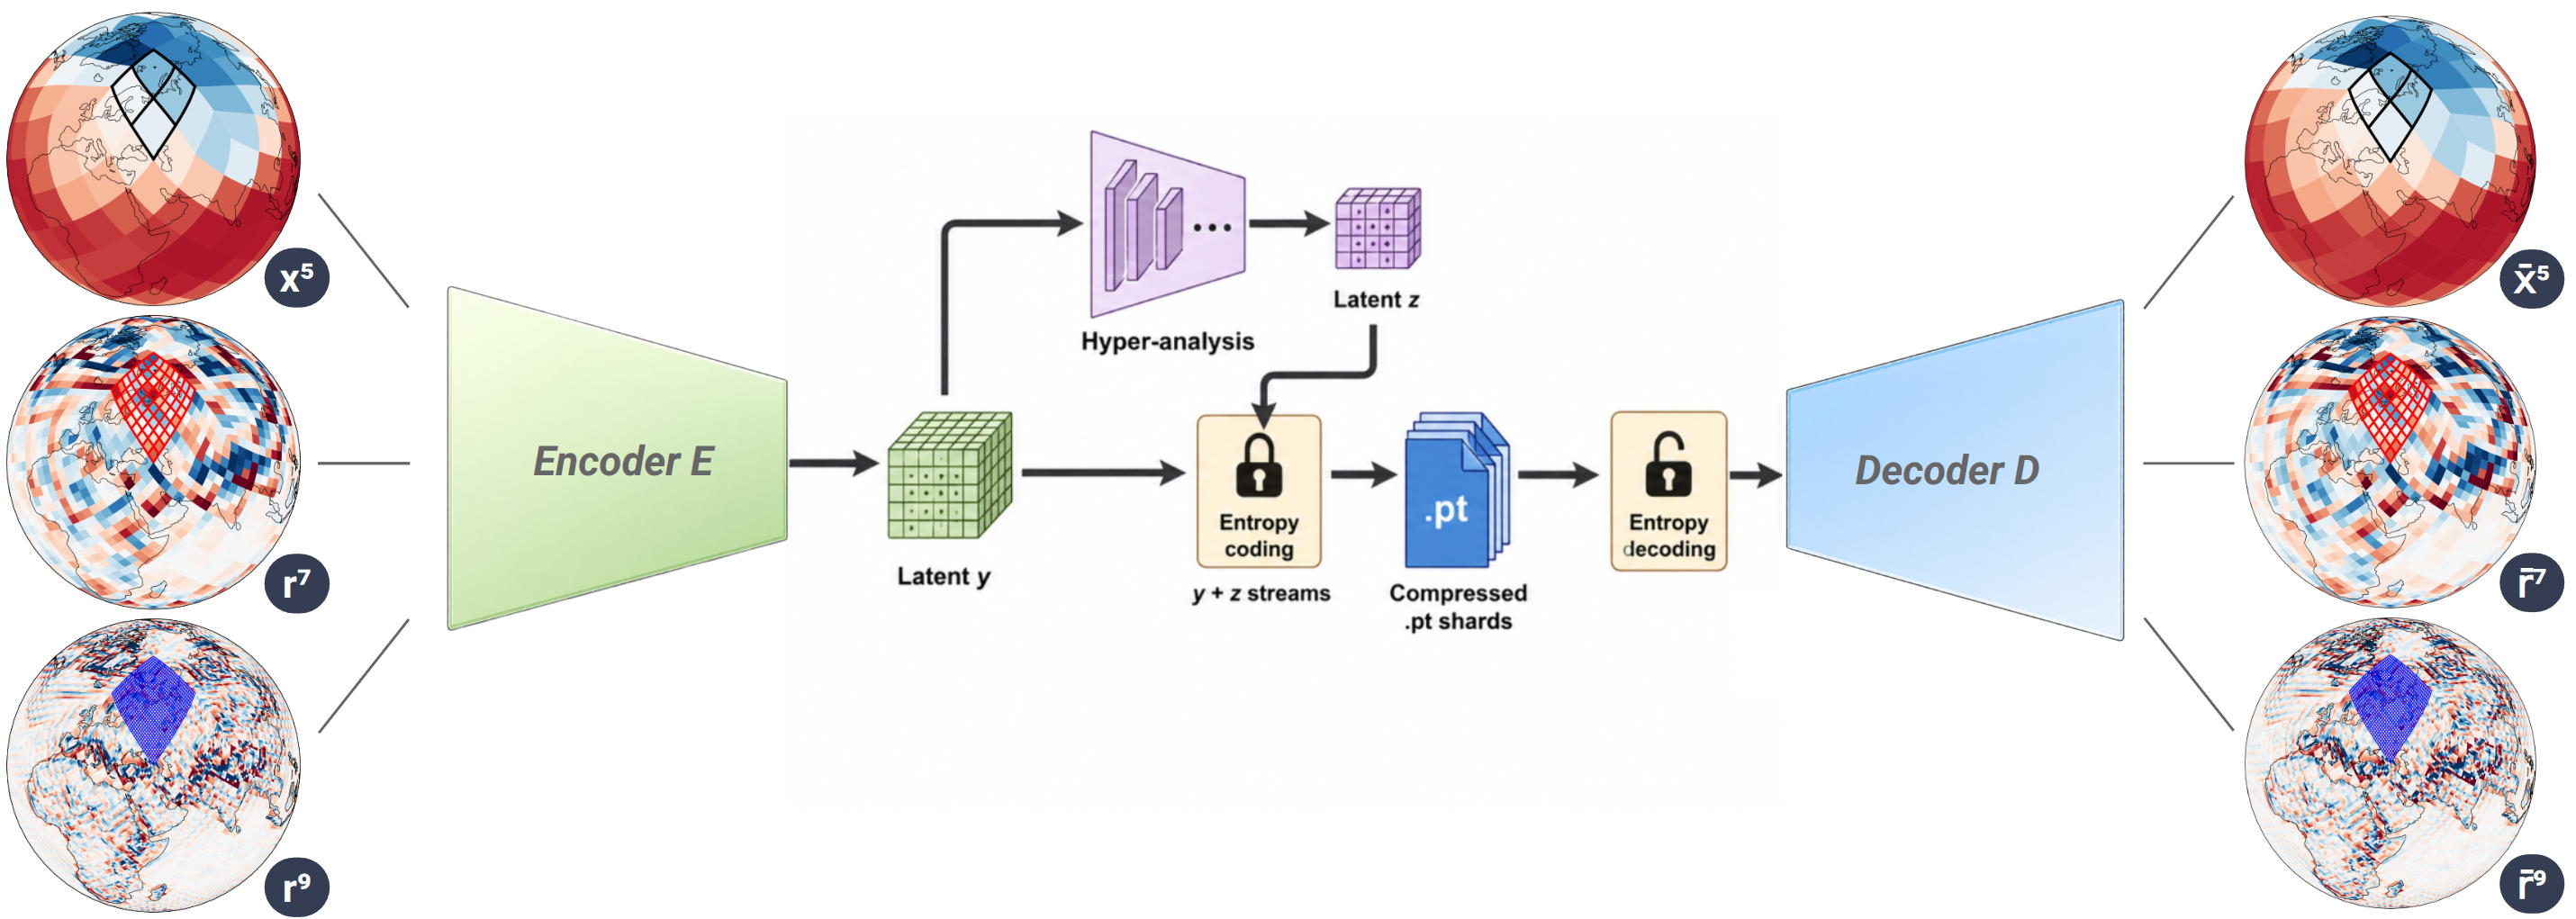

## 1. Environment and imports

This cell locates the notebook-local helpers, configures writable plotting caches on cluster nodes, imports the installed FieldSpaceNN package, and reports the available compute device. A CPU is supported, but loading and running the high-resolution example can be slow.

In [ ]:
import os
import sys
import json
import random
import time
from functools import partial
from pathlib import Path
from typing import Any, Dict, List

# Configure caches before importing matplotlib.
os.environ.setdefault('MPLCONFIGDIR', '/tmp/fieldspacenn-mpl-cache')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/fieldspacenn-xdg-cache')
os.environ["SLURM_JOB_NAME"] = "interactive"
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
import torch
from tqdm.auto import tqdm
from hydra.utils import instantiate
from IPython.display import Markdown, display

# Locate notebook-local helpers whether Jupyter starts in the repo root or notebooks/.
search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
NOTEBOOK_DIR = next(
    path
    for root in search_roots
    for path in (root, root / 'notebooks')
    if (path / 'utils.py').is_file()
)
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from utils import (
    build_scorecard, clean_generated_outputs, collate_dataset_sample,
    dataset_time_index, effective_sample_configs, indexed_item,
    inference_experiment_summary, load_plotting_example, load_shard, merge_time_side_info,
    metrics_from_accumulators,
    plot_decomposed_input_zooms, plot_input_zooms, plot_rmse_vs_compression,
    save_evaluation_summary, synchronize, to_cpu, to_device,
    validate_inference_setup, write_json, write_shard, export_decoded_zarr
)

# FieldSpaceNN is imported directly from the active environment.

from fieldspacenn.src.modules.grids.grid_utils import decode_zooms
from fieldspacenn.src.utils.helpers import load_from_state_dict

print(f'Python: {sys.executable}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()} ({torch.cuda.device_count()} device(s))')

## 2. Experiment controls

This cell controls artifact organization and execution resources. `SHARD_SIZE` is the number of compressed sample records grouped into each `.pt` file. `COMPACT_ARTIFACT_FORMAT=True` batches tensor side information, stores repeated metadata once per shard, and concatenates corresponding entropy streams with offset tables. Set it to `False` only when the original record-per-sample `.pt` layout is required. Neither setting changes the reconstruction.

The default output location is outside `snapshots`. Known artifacts from the same profile are overwritten on every run; unrelated files are left untouched.

In [ ]:
OUTPUT_ROOT = NOTEBOOK_DIR / 'evaluations' / 'hackathon_hyperprior'
SHARD_SIZE = 8                 # compressed sample records stored in each .pt shard
COMPACT_ARTIFACT_FORMAT = True # compact batched shards; False preserves the legacy layout
DEVICE_POLICY = 'auto'         # 'auto', 'cuda', or 'cpu'
NUM_WORKERS = 0                # zero is safest inside notebooks
RANDOM_SEED = 42               # set for reproducability

# Make repeated runs deterministic where the underlying operations permit it.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## 3. Model profile registry and validation

A checkpoint is coupled to its variables, normalizers, embeddings, depth layout, and grid resolutions. A registry entry therefore selects these as one compatible unit instead of offering unsafe independent dropdowns. Its `variables` mapping may contain `2D`, `3D`, or both groups. Every variable defines the highest-resolution input `path`; `level_indices` selects one level for a 2-D group or an arbitrary equal-length subset for a 3-D group, while `None` retains all levels for a 3-D variable. It may also contain a reserved `timesteps` list with individual integer indices and end-exclusive ranges such as `"5-100"`; omit it to run the inference on the complete data set. Group and variable order must match the saved model configuration.

This cell composes the saved Hydra configuration, injects the profile data sources into the test split, and validates paths, variables, levels, and resolutions before allocating the large model. Lower-resolution inputs are generated lazily from the profile's highest-resolution stores.

**Common failure:** moving or renaming a checkpoint, config, data store, or normalization JSON produces an early path-validation error.

In [ ]:
MODEL_PROFILES = {
    'hpx9_tas': {
        'label': 'NextGEMS Cycle 4: tas at HPX9',
        'config_path': '/p/project1/training2640/meuer1/snapshots/hpx9_tas/composed_config.yaml',
        'checkpoint_path': '/p/project1/training2640/meuer1/snapshots/hpx9_tas/last.ckpt',
        'variables': {
            # Optional: [0, 1, 2, '5-100', 1000]
            'timesteps': [0],
            '2D': {
                'tas': {'path': '/p/project1/training2640/meuer1/data/nextGEMS_level9.zarr'},
            },
        },
        'expected_zooms': [5, 7, 9],
    },
    'hpx9_pr_ua_va_hus': {
        'label': 'NextGEMS Cycle 4: pr / ua / va / hus at HPX9',
        'config_path': '/p/project1/training2640/meuer1/snapshots/hpx9_pr_ua_va_hus/composed_config.yaml',
        'checkpoint_path': '/p/project1/training2640/meuer1/snapshots/hpx9_pr_ua_va_hus/last.ckpt',
        'variables': {
            'timesteps': [0],
            '2D': {
                'pr': {'path': '/p/project1/training2640/meuer1/data/EW3_ICON_ngc4008_90d_Compression_test.zarr'}
            },
            '3D': {
                'ua': {'path': '/p/project1/training2640/meuer1/data/EW3_ICON_ngc4008_90d_Compression_test.zarr'},
                'va': {'path': '/p/project1/training2640/meuer1/data/EW3_ICON_ngc4008_90d_Compression_test.zarr'},
                'hus': {'path': '/p/project1/training2640/meuer1/data/EW3_ICON_ngc4008_90d_Compression_test.zarr'}
            },
        },
        'expected_zooms': [5, 7, 9],
    }
}
MODEL_PROFILE = 'hpx9_tas'

# One helper composes the config and performs every profile, path, and control check.
experiment = validate_inference_setup(
    MODEL_PROFILES, MODEL_PROFILE, OUTPUT_ROOT, DEVICE_POLICY, SHARD_SIZE, NUM_WORKERS
)
display(inference_experiment_summary(experiment))

## 4. Load the pretrained codec

Hydra reconstructs the model architecture from the saved configuration. The checkpoint loader restores learned weights, and `update(force=True)` builds the cumulative-distribution tables required by the entropy coder. Model-loading time is kept separate from compression time.

**Common failure:** an out-of-memory error here means the selected device cannot hold the model; choose a larger GPU or set `DEVICE_POLICY='cpu'`.

In [ ]:
# Recreate the architecture first, then restore only the saved learned state.
load_started = time.perf_counter()
lightning_model = instantiate(experiment.cfg.model)
lightning_model, matching_keys = load_from_state_dict(
    lightning_model, experiment.checkpoint_path, device='cpu', print_keys=False
)
lightning_model.to(experiment.device)
lightning_model.eval()
# Build entropy-model lookup tables once before calling the codec API directly.
codec = lightning_model.model
codec.update(force=True)
MODEL_LOAD_SECONDS = time.perf_counter() - load_started
parameter_count = sum(parameter.numel() for parameter in lightning_model.parameters())
print(f'Loaded {len(matching_keys):,} checkpoint tensors in {MODEL_LOAD_SECONDS:.2f} s')
print(f'Model parameters: {parameter_count:,}')
print(f'Model device: {next(lightning_model.parameters()).device}')

## 5. Prepare test data

The test dataset uses the saved training configuration for 2-D/3-D group order, normalization and depth layout. A profile-level `timesteps` defines the test split (omit when you want to run inference on the full data set), while profile paths and optional vertical-level selections choose the input stores. Batch size one makes every saved record correspond to exactly one dataset index and simplifies restartable streaming.

The shape table reports tensors exactly as the encoder receives them: `(batch, variable, time, pixel, depth, feature)`. Two normalized map previews then show the selected input sample in complementary forms. **Raw data before decomposition at different resolutions** composes the multiscale tensors independently at every configured zoom. **Decomposed data: base field and residuals** shows the base field and signed refinement tensors passed to the model. Neither plot denormalizes the data.

**Common failure:** opening remote Zarr stores can take a little time; a path or permissions error will appear here before compression begins. A 2-D group variable must resolve to one level, while every variable in a 3-D group must resolve to the same depth.

In [ ]:
# Recreate the exact test dataset and collator saved with the checkpoint.
test_dataset = instantiate(
    experiment.cfg.dataloader.dataset, data_dict=experiment.cfg.data_split.test
)
data_module = instantiate(
    experiment.cfg.dataloader.datamodule,
    dataset_test=test_dataset,
    batch_size=1,
    num_workers=NUM_WORKERS,
)

# The profile's optional `timesteps` selection is already reflected in dataset length.
dataset_indices = list(range(len(test_dataset)))
if not dataset_indices:
    raise ValueError('The configured profile selects no inference samples.')

# Preview one collated encoder input so shape and dtype problems appear early.
load_sample = partial(collate_dataset_sample, test_dataset, data_module.test_collator)
preview_batch = load_sample(dataset_indices[0])
preview_source = preview_batch[0]
shape_rows = []
for group_index, group in enumerate(preview_source):
    for zoom, tensor in group.items():
        shape_rows.append({'group': group_index, 'zoom': int(zoom), 'shape': tuple(tensor.shape), 'dtype': str(tensor.dtype)})
display(pd.DataFrame(shape_rows).sort_values(['group', 'zoom']).reset_index(drop=True))
print(f'Dataset samples: {len(test_dataset):,}')
print(f'Inference samples: {len(dataset_indices):,}')
print(f'Normalization enabled: {test_dataset.normalize_data}')
del preview_batch, preview_source

# Show the normalized fields before decomposition at each configured resolution.
RAW_INPUT_PREVIEW_PATH = experiment.output_dir / 'input_zoom_preview.png'
raw_input_figure, raw_input_maps = plot_input_zooms(
    test_dataset, RAW_INPUT_PREVIEW_PATH, sample_index=dataset_indices[0]
)
plt.show()

# Show the base field and signed residual tensors that enter the encoder.
DECOMPOSED_INPUT_PREVIEW_PATH = experiment.output_dir / 'input_zoom_decomposition.png'
decomposed_input_figure, decomposed_input_maps = plot_decomposed_input_zooms(
    test_dataset, DECOMPOSED_INPUT_PREVIEW_PATH, sample_index=dataset_indices[0]
)
plt.show()
print(f'Raw input preview: {RAW_INPUT_PREVIEW_PATH}')
print(f'Decomposed input preview: {DECOMPOSED_INPUT_PREVIEW_PATH}')

## 6. Compress and write real artifacts

The analysis transform maps the multiresolution inputs to latent variables. A hyper-analysis transform produces `z`, which communicates a probability model for coding `y`. Both are entropy-coded, while the configured zoom-5 passthrough and embedding metadata are stored as side information.

Records are buffered into shards of at most `SHARD_SIZE`. The selected writer handles compact or legacy serialization internally, and a `tqdm` bar tracks completed samples. Codec time and disk-write time are recorded separately. The raw reference size counts only float32 values at HPX9, as chosen for this benchmark.

In [ ]:
# Start a fresh artifact bundle while preserving unrelated files in the directory.
clean_generated_outputs(
    experiment.output_dir,
    preserve=('input_zoom_preview.png', 'input_zoom_decomposition.png'),
)
shard_paths: List[Path] = []
shard_records: List[Dict[str, Any]] = []
compression_seconds = 0.0
write_seconds = 0.0
raw_hpx9_values = 0

# Encode one selected timestep at a time so the run has bounded memory use.
for run_position, dataset_index in enumerate(
    tqdm(dataset_indices, desc='Compressing', unit='sample')
):
    source_groups, _, mask_groups, embedding_groups, patch_index_zooms = load_sample(dataset_index)
    batch_size = next(iter(source_groups[0].values())).shape[0]
    if batch_size != 1:
        raise ValueError(f'Expected batch size 1, got {batch_size}')
    # Count only finest-grid float32 inputs for the uncompressed-size reference.
    raw_hpx9_values += int(sum(
        group[experiment.max_zoom].numel()
        for group in source_groups if experiment.max_zoom in group
    ))
    sample_configs = effective_sample_configs(test_dataset, codec, patch_index_zooms)
    source_device = to_device(source_groups, experiment.device)
    masks_device = to_device(mask_groups, experiment.device)
    embeddings_device = to_device(embedding_groups, experiment.device)
    configs_device = to_device(sample_configs, experiment.device)

    # Synchronization keeps CUDA codec timing separate from asynchronous kernel launch time.
    synchronize(experiment.device)
    started = time.perf_counter()
    with torch.inference_mode():
        encoded = codec.compress(
            source_device,
            sample_configs=configs_device,
            mask_zooms_groups=masks_device,
            emb_groups=embeddings_device,
        )
    synchronize(experiment.device)
    compression_seconds += time.perf_counter() - started

    # Move entropy streams and required decoder side information to CPU before saving.
    record = {
        'dataset_index': int(dataset_index),
        'run_position': int(run_position),
        'time_index': dataset_time_index(test_dataset, experiment.max_zoom, dataset_index),
        'strings': {
            'y': to_cpu(encoded['strings']['y']),
            'z': to_cpu(encoded['strings']['z']),
        },
        'metadata': {
            'y': to_cpu(encoded['metadata']['y']),
            'z': to_cpu(encoded['metadata']['z']),
            'y_specs': to_cpu(encoded['metadata']['y_specs']),
            'z_specs': to_cpu(encoded['metadata']['z_specs']),
            'sample_configs': to_cpu(encoded['metadata']['sample_configs']),
            'embedding_side_info': to_cpu(encoded['metadata']['embedding_side_info']),
            'passthrough': to_cpu(encoded['metadata']['passthrough']),
        },
    }
    # Time embeddings are not returned by compress(), but standalone decoding needs them.
    record['metadata']['embedding_side_info'] = merge_time_side_info(
        indexed_item(embedding_groups, 0), record['metadata']['embedding_side_info']
    )
    shard_records.append(record)
    # Flush a complete shard immediately instead of retaining the full run in memory.
    if len(shard_records) == SHARD_SIZE:
        shard_path, shard_write_seconds = write_shard(
            shard_records, experiment.output_dir, len(shard_paths),
            compact_artifact_format=COMPACT_ARTIFACT_FORMAT,
        )
        shard_paths.append(shard_path)
        write_seconds += shard_write_seconds
        shard_records = []

if shard_records:
    shard_path, shard_write_seconds = write_shard(
        shard_records, experiment.output_dir, len(shard_paths),
        compact_artifact_format=COMPACT_ARTIFACT_FORMAT,
    )
    shard_paths.append(shard_path)
    write_seconds += shard_write_seconds
# Charge the benchmark for the complete serialized shard size, including metadata overhead.
artifact_bytes = sum(path.stat().st_size for path in shard_paths)
raw_hpx9_bytes = raw_hpx9_values * 4
manifest = {
    'format_version': 2 if COMPACT_ARTIFACT_FORMAT else 1,
    'compact_artifact_format': COMPACT_ARTIFACT_FORMAT,
    'model_profile': MODEL_PROFILE,
    'profile_label': experiment.profile['label'],
    'config_path': experiment.config_path,
    'checkpoint_path': experiment.checkpoint_path,
    'variables': experiment.configured_variables,
    'variable_groups': experiment.configured_variable_groups,
    'zooms': experiment.configured_zooms,
    'max_zoom': experiment.max_zoom,
    'dataset_indices': dataset_indices,
    'time_indices': [
        dataset_time_index(test_dataset, experiment.max_zoom, index)
        for index in dataset_indices
    ],
    'shard_size': SHARD_SIZE,
    'shards': [{'name': path.name, 'bytes': path.stat().st_size} for path in shard_paths],
    'input_preview_files': [RAW_INPUT_PREVIEW_PATH.name, DECOMPOSED_INPUT_PREVIEW_PATH.name],
    'sample_count': len(dataset_indices),
    'raw_size_definition': 'float32 bytes of normalized HPX9 encoder inputs only',
    'raw_hpx9_values': raw_hpx9_values,
    'raw_hpx9_bytes': raw_hpx9_bytes,
    'artifact_bytes': artifact_bytes,
    'model_load_seconds': MODEL_LOAD_SECONDS,
    'compression_seconds': compression_seconds,
    'artifact_write_seconds': write_seconds,
    'device': str(experiment.device),
}
write_json(experiment.output_dir / 'manifest.json', manifest)
print(f'Wrote {len(shard_paths)} shard(s) to {experiment.output_dir}')
print(f'Artifact size: {artifact_bytes / 2**20:.2f} MiB')

## 7. Read, decompress, and evaluate as a stream

This stage reloads every shard from disk rather than reusing encoder memory. A sample-level `tqdm` bar advances across shard boundaries. The decoder reconstructs every normalized 2-D/3-D group, `decode_zooms` composes each output at the maximum zoom, and the dataset normalizers restore physical values. Ground truth is reloaded by the recorded dataset index.

For each variable, running sums are sufficient for RMSE, MAE, bias, and correlation, so no full-resolution reconstruction is retained. Section 9 reloads only the artifact selected for plotting. HEALPix pixels have equal area, so ordinary pixel averages are also area-weighted global averages.

**Common failure:** decoding with a different checkpoint/profile is unsafe. The manifest identity is checked before any shard is read.

In [ ]:
# Refuse to decode artifacts produced by a different profile or dataset selection.
saved_manifest = json.loads(
    (experiment.output_dir / 'manifest.json').read_text(encoding='utf-8')
)
if saved_manifest['model_profile'] != MODEL_PROFILE:
    raise ValueError('Artifact manifest does not match the selected model profile.')
if saved_manifest['dataset_indices'] != dataset_indices:
    raise ValueError('Artifact manifest does not match the selected dataset indices.')

# Sufficient statistics avoid retaining full-resolution reconstructions in memory.
accumulators = {
    variable: {'count': 0, 'sum_abs_error': 0.0, 'sum_squared_error': 0.0, 'sum_error': 0.0,
               'sum_target': 0.0, 'sum_prediction': 0.0, 'sum_target_sq': 0.0,
               'sum_prediction_sq': 0.0, 'sum_cross': 0.0}
    for variable in experiment.configured_variables
}
decompression_seconds = 0.0
normalizer_zoom = max(int(zoom) for zoom in test_dataset.var_normalizers.keys())
decoded_count = 0

# Reload every shard from disk to exercise a genuine serialized round trip.
decompression_progress = tqdm(
    total=len(dataset_indices), desc='Decompressing', unit='sample'
)
for shard_info in saved_manifest['shards']:
    records = load_shard(experiment.output_dir / shard_info['name'])
    for record in records:
        dataset_index = int(record['dataset_index'])
        _, target_groups, _, _, _ = load_sample(dataset_index)
        metadata_device = to_device(record['metadata'], experiment.device)
        strings_device = to_device(record['strings'], experiment.device)
        # Time entropy decoding and synthesis independently from disk and target loading.
        synchronize(experiment.device)
        started = time.perf_counter()
        with torch.inference_mode():
            decoded = codec.decompress(
                strings_device,
                metadata_device,
                sample_configs=metadata_device['sample_configs'],
                out_zoom=experiment.max_zoom,
            )
        synchronize(experiment.device)
        decompression_seconds += time.perf_counter() - started

        # Compose and evaluate every 2-D/3-D group on the finest HEALPix grid.
        sample_configs_cpu = record['metadata']['sample_configs']
        for group_index, (group_name, group_variables) in enumerate(
            experiment.configured_variable_groups.items()
        ):
            reconstructed_group = decode_zooms(
                to_cpu(decoded['x_hat'][group_index]),
                sample_configs=sample_configs_cpu,
                out_zoom=experiment.max_zoom,
            )
            target_group = decode_zooms(
                to_cpu(target_groups[group_index]),
                sample_configs=sample_configs_cpu,
                out_zoom=experiment.max_zoom,
            )
            reconstructed_tensor = reconstructed_group[experiment.max_zoom].float()
            target_tensor = target_group[experiment.max_zoom].float()
            if reconstructed_tensor.shape != target_tensor.shape:
                raise ValueError(f'Reconstruction/target mismatch: {reconstructed_tensor.shape} vs {target_tensor.shape}')
            if reconstructed_tensor.shape[1] != len(group_variables):
                raise ValueError(f'Decoded variable axis does not match group {group_name!r}.')
            if reconstructed_tensor.shape[-2] != experiment.variable_group_levels[group_name]:
                raise ValueError(f'Decoded depth axis does not match group {group_name!r}.')

            # Denormalize each variable; 3-D metrics pool all selected levels.
            for variable_index, variable in enumerate(group_variables):
                normalizer = test_dataset.var_normalizers[normalizer_zoom][variable]
                prediction = normalizer.denormalize(reconstructed_tensor[:, variable_index:variable_index + 1]).double()
                target = normalizer.denormalize(target_tensor[:, variable_index:variable_index + 1]).double()
                prediction_flat = prediction.reshape(-1)
                target_flat = target.reshape(-1)
                error = prediction_flat - target_flat
                stats = accumulators[variable]
                stats['count'] += int(error.numel())
                stats['sum_abs_error'] += float(error.abs().sum())
                stats['sum_squared_error'] += float(error.square().sum())
                stats['sum_error'] += float(error.sum())
                stats['sum_target'] += float(target_flat.sum())
                stats['sum_prediction'] += float(prediction_flat.sum())
                stats['sum_target_sq'] += float(target_flat.square().sum())
                stats['sum_prediction_sq'] += float(prediction_flat.square().sum())
                stats['sum_cross'] += float((target_flat * prediction_flat).sum())
        decoded_count += 1
        decompression_progress.update(1)
decompression_progress.close()

if decoded_count != len(dataset_indices):
    raise RuntimeError(f'Expected {len(dataset_indices)} decoded samples, got {decoded_count}')

## 8. Hackathon scorecard

The headline compression ratio is `raw HPX9 float32 bytes / complete .pt shard bytes`. Consequently, entropy streams, passthrough tensors, metadata, and PyTorch container overhead are all charged to the compressed representation. Artifact bits per value uses the same complete artifact size.

RMSE emphasizes large errors, MAE summarizes typical absolute error, and bias reveals systematic over- or under-prediction. The total row pools scalar errors across variables, even though their physical units differ, so per-variable rows should drive scientific interpretation.

**Common failure:** non-finite metrics usually indicate non-finite source values or a checkpoint/data mismatch and trigger an assertion here.

In [ ]:
# Turn streaming sums into metrics and assemble all rate/timing measurements.
metrics_df = metrics_from_accumulators(accumulators)
scorecard = build_scorecard(
    sample_count=len(dataset_indices),
    raw_hpx_bytes=raw_hpx9_bytes,
    raw_hpx_values=raw_hpx9_values,
    artifact_bytes=artifact_bytes,
    model_load_seconds=MODEL_LOAD_SECONDS,
    compression_seconds=compression_seconds,
    decompression_seconds=decompression_seconds,
    artifact_write_seconds=write_seconds,
)
compression_ratio = scorecard['compression_ratio_raw_hpx9_over_artifact']
artifact_bits_per_value = scorecard['artifact_bits_per_hpx9_value']

# Persist the tables and update the manifest with the evaluation outputs.
manifest = save_evaluation_summary(
    experiment.output_dir, metrics_df, scorecard, manifest
)

display(pd.Series(scorecard).to_frame('value').style.format({'value': '{:,.4g}'}))
core_columns = ['variable', 'values', 'RMSE', 'MAE', 'bias']
display(metrics_df[core_columns].style.format({'values': '{:,.0f}', 'RMSE': '{:.6g}', 'MAE': '{:.6g}', 'bias': '{:.6g}'}))

## 9. Selected reconstruction maps

Set `PLOT_VARIABLE` directly to a configured variable name such as `"tas"`, then choose `PLOT_LEVEL_INDEX` (zero for 2D variables) and `PLOT_SAMPLE_INDEX`. Rerun this cell (and optionally Section 10) to inspect another saved field without repeating compression or evaluation. The level index is the position within the selected levels of a 3-D variable; it remains zero for a 2-D variable. The sample index is a position within this run, not the underlying dataset index.

These Mollweide maps show physical ground truth, decoded reconstruction, and signed error (`reconstruction - ground truth`). Ground truth and reconstruction share color limits; the error scale is symmetric around zero.

**Common failure:** an unknown variable, invalid selected-level position, or sample position outside the saved run is rejected before decoding. `healpy` then validates that the selected slice is a one-dimensional full-sphere map.

In [ ]:
# These controls affect visualization only; edit them without rerunning earlier sections.
PLOT_VARIABLE = 'tas'          # actual variable name from the selected model profile
PLOT_LEVEL_INDEX = 0          # selected depth position; keep zero for a 2D variable
PLOT_SAMPLE_INDEX = 0         # position within this saved run, not the dataset index

# Reload and decode just the requested artifact record.
plot_example = load_plotting_example(
    output_dir=experiment.output_dir,
    manifest=manifest,
    plot_sample_index=PLOT_SAMPLE_INDEX,
    plot_variable=PLOT_VARIABLE,
    plot_level_index=PLOT_LEVEL_INDEX,
    configured_variables=experiment.configured_variables,
    configured_variable_groups=experiment.configured_variable_groups,
    dataset=test_dataset,
    load_sample=load_sample,
    codec=codec,
    device=experiment.device,
    max_zoom=experiment.max_zoom,
)
plot_dataset_index = plot_example['dataset_index']
target_map = np.asarray(plot_example['target']).squeeze()
prediction_map = np.asarray(plot_example['prediction']).squeeze()
if target_map.ndim != 1 or prediction_map.shape != target_map.shape:
    raise ValueError(f'Expected matching 1-D maps, got {target_map.shape} and {prediction_map.shape}')
expected_pixels = hp.nside2npix(2 ** experiment.max_zoom)
if target_map.size != expected_pixels:
    raise ValueError(
        f'Expected {expected_pixels} HPX{experiment.max_zoom} pixels, got {target_map.size}'
    )
# Use shared field limits and a symmetric signed-error scale for fair comparison.
error_map = prediction_map - target_map
field_min = float(min(target_map.min(), prediction_map.min()))
field_max = float(max(target_map.max(), prediction_map.max()))
error_limit = float(max(abs(error_map.min()), abs(error_map.max()), 1e-12))
fig = plt.figure(figsize=(18, 5))
plot_label = f'{PLOT_VARIABLE} · level {plot_example["level_index"]}'
hp.mollview(target_map, nest=True, fig=fig.number, sub=(1, 3, 1), title=f'{plot_label}: ground truth', cmap='RdBu_r', min=field_min, max=field_max)
hp.mollview(prediction_map, nest=True, fig=fig.number, sub=(1, 3, 2), title=f'{plot_label}: reconstruction', cmap='RdBu_r', min=field_min, max=field_max)
hp.mollview(error_map, nest=True, fig=fig.number, sub=(1, 3, 3), title='signed error', cmap='RdBu_r', min=-error_limit, max=error_limit)
fig.suptitle(f'Dataset index {plot_dataset_index} · time index {plot_example["time_index"]}', y=1.02, fontsize=14)
figure_path = experiment.output_dir / 'reconstruction_maps.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved {figure_path}')

## 10. Optional deeper scientific diagnostics

Inspect correlation, a sampled value distribution/scatter plot, angular power spectra, and a rate–distortion comparison with the next three lower HEALPix levels. For the HPX9 reconstruction, the baseline points are HPX8, HPX7, and HPX6. Power spectra test whether spatial variance is preserved across scales, rather than only pixel by pixel.

Nested HEALPix maps are reordered to ring ordering before `anafast`. For each resolution baseline, the selected ground-truth map is degraded to coarse cell averages and then upgraded by assigning each parent value to its nested children. The baseline x-axis uses theoretical pixel-count reduction, while the model point uses the measured complete-artifact compression ratio. RMSE values in this plot are all calculated on the selected sample.

**Common failure:** spherical harmonic analysis is computationally heavier than the core dashboard and is skipped entirely by default.

In [ ]:
# Sample pixels for responsive scatter/histogram plots, but use full maps for spectra.
rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(100_000, target_map.size)
sampled_pixels = rng.choice(target_map.size, size=sample_size, replace=False)
# healpy's spherical-harmonic transform expects ring rather than nested ordering.
target_ring = hp.reorder(target_map, n2r=True)
prediction_ring = hp.reorder(prediction_map, n2r=True)
spectrum_target = hp.anafast(target_ring)
spectrum_prediction = hp.anafast(prediction_ring)
ell = np.arange(len(spectrum_target))
relative_spectral_error = np.abs(spectrum_prediction - spectrum_target) / np.maximum(np.abs(spectrum_target), 1e-30)

model_rmse = float(np.sqrt(np.mean((prediction_map - target_map) ** 2)))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].scatter(target_map[sampled_pixels], prediction_map[sampled_pixels], s=2, alpha=0.15)
lo = min(target_map[sampled_pixels].min(), prediction_map[sampled_pixels].min())
hi = max(target_map[sampled_pixels].max(), prediction_map[sampled_pixels].max())
axes[0, 0].plot([lo, hi], [lo, hi], 'k--', linewidth=1)
axes[0, 0].set(xlabel='ground truth', ylabel='reconstruction', title=f'{PLOT_VARIABLE}: sampled pixels')
axes[0, 1].hist(target_map[sampled_pixels], bins=80, density=True, alpha=0.55, label='ground truth')
axes[0, 1].hist(prediction_map[sampled_pixels], bins=80, density=True, alpha=0.55, label='reconstruction')
axes[0, 1].set(title='Value distribution', xlabel=PLOT_VARIABLE, ylabel='density')
axes[0, 1].legend()
axes[1, 0].loglog(ell[1:], spectrum_target[1:], label='ground truth')
axes[1, 0].loglog(ell[1:], spectrum_prediction[1:], label='reconstruction')
axes[1, 0].set(title='Angular power spectrum', xlabel='multipole ℓ', ylabel='Cℓ')
axes[1, 0].legend()
axes[1, 1].semilogy(ell[1:], relative_spectral_error[1:])
axes[1, 1].set(title='Relative spectral error', xlabel='multipole ℓ', ylabel='relative error')
fig.suptitle(f'{PLOT_VARIABLE} · selected-sample model RMSE={model_rmse:.5g}')
fig.tight_layout()
deep_path = experiment.output_dir / 'deep_diagnostics.png'
fig.savefig(deep_path, dpi=160, bbox_inches='tight')
plt.show()

# Compare the learned codec with three nearest-neighbor lower-resolution baselines.
rate_comparison = plot_rmse_vs_compression(
    target_map=target_map,
    prediction_map=prediction_map,
    model_compression_ratio=compression_ratio,
    original_zoom=experiment.max_zoom,
    variable_name=PLOT_VARIABLE,
    output_path=experiment.output_dir / 'rmse_vs_compression.png',
    n_lower_levels=3,
)
rate_rows = [
    {'representation': f'HPX{zoom} baseline', 'compression_ratio': ratio, 'RMSE': rmse}
    for zoom, ratio, rmse in zip(
        rate_comparison['baseline_zooms'],
        rate_comparison['baseline_compression_ratios'],
        rate_comparison['baseline_rmse'],
    )
]
rate_rows.append({
    'representation': 'Hyperprior autoencoder',
    'compression_ratio': rate_comparison['model_compression_ratio'],
    'RMSE': rate_comparison['model_rmse'],
})
display(pd.DataFrame(rate_rows).style.format({'compression_ratio': '{:.2f}×', 'RMSE': '{:.6g}'}))
display(metrics_df[['variable', 'Pearson r']].style.format({'Pearson r': '{:.6f}'}))
print(f'Saved {deep_path} and {rate_comparison["output_path"]}')

## 12. Conclusion

The final cell turns the main measurements into a short presentation-ready statement and lists the complete output bundle. Remember that a higher compression ratio is useful only when the per-variable errors and spatial diagnostics remain acceptable for the intended scientific application.

In [ ]:
# Convert the scorecard into a concise presentation-ready summary and artifact inventory.
display(Markdown(
    f'### Result summary\n'
    f'Compressed **{len(dataset_indices):,} sample(s)** from **{raw_hpx9_bytes / 2**20:.2f} MiB** of raw HPX9 float32 values '
    f'to **{artifact_bytes / 2**20:.2f} MiB** of complete artifacts: **{compression_ratio:.2f}× compression** '
    f'at **{artifact_bits_per_value:.3f} bits/value**. Compression took **{compression_seconds:.2f} s** and '
    f'decompression took **{decompression_seconds:.2f} s**. See the table above for physical-space fidelity by variable.'
))

## 13. Export decoded fields to Zarr

This final cell creates an independently usable Zarr dataset containing the **decoded, denormalized reconstructions**. It does not write latent tensors or entropy streams. The saved compressed shards are read back and decoded one at a time, so the export remains memory-bounded for long runs.

The original input stores are used only as metadata templates. The exporter restores the original variable dimension order, selected timestamps, selected vertical-level coordinates, spatial dimension, variable and coordinate attributes, dataset attributes, and referenced CF grid-mapping metadata. It also adds FieldSpaceNN provenance attributes identifying the profile, configuration, checkpoint, and source paths. Storage chunks may differ from the source because decoded values are written as float32 reconstruction fields.

The resulting `decoded_fields.zarr` can be opened in a separate analysis with `xarray.open_zarr(...)` and compared directly with the corresponding original timesteps. `OVERWRITE_DECODED_ZARR=True` replaces only this named output after a complete temporary store has been written successfully.

**Common failure:** source metadata must still be accessible during export. Overlapping temporal windows are rejected because they would create duplicate time coordinates; the inference profiles used by this notebook normally reconstruct one unique timestep per artifact record.


In [ ]:
# Choose the standalone reconstruction store written inside this experiment directory.
DECODED_ZARR_PATH = experiment.output_dir / 'decoded_fields.zarr'
OVERWRITE_DECODED_ZARR = True

# Decode shards sequentially, denormalize the fields, and attach source metadata.
decoded_zarr_summary = export_decoded_zarr(
    output_path=DECODED_ZARR_PATH,
    manifest=manifest,
    experiment=experiment,
    dataset=test_dataset,
    codec=codec,
    overwrite=OVERWRITE_DECODED_ZARR,
)

# Display the information needed to open and inspect the independent dataset.
display(pd.Series({
    'Path': decoded_zarr_summary['path'],
    'Variables': ', '.join(decoded_zarr_summary['variables']),
    'Dimensions': str(decoded_zarr_summary['sizes']),
    'Decoded timesteps': decoded_zarr_summary['time_steps'],
    'Store size (GiB)': f"{decoded_zarr_summary['store_bytes'] / 2**30:.3f}",
}).to_frame('value'))
